<a href="https://colab.research.google.com/github/anumit2004/Exploratory_Data_Analysis-EDA-/blob/main/EDA_Play_store_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## EDA And Feature Engineering Of Google Play Store Dataset

1) Problem statement.
Today, 1.85 million different apps are available for users to download. Android users have even more from which to choose, with 2.56 million available through the Google Play Store. These apps have come to play a huge role in the way we live our lives today. Our Objective is to find the Most Popular Category, find the App with largest number of installs , the App with largest size etc.
2) Data Collection.

The data consists of 20 column and 10841 rows.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
df= pd.read_csv('/content/Play_store_data.csv')
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
df.shape

(10841, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [5]:
df['Reviews'].unique()

array(['159', '967', '87510', ..., '603', '1195', '398307'], dtype=object)

In [6]:
df['Reviews'].str.isnumeric().sum()

np.int64(10840)

In [7]:
df[ df['Reviews'] == '3.0M']

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [8]:
#function used to convert string to int takling M and K
def convert(val):
  if isinstance(val, str):
    if val.endswith('M'):
      return int(float(val[:-1])*1000000)
    elif val.endswith('K'):
      return int(float(val[:-1])*1000)
  return int(val)

df['Reviews']  = df['Reviews'].apply(convert)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  int64  
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 1.1+ MB


In [10]:
df['Size'].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k',
       '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

In [11]:
#convert to int values for size in M and k
def convert_numeric(val):
  val = val.replace(',','')
  if isinstance(val,str):
    if val.endswith('M'):
      return int(float(val[:-1])*1000000)
    elif val.endswith('k'):
      return int(float(val[:-1])*1000)
    elif val.endswith('+'):
      str_num  = val[:-1]
      return int(str_num)
    elif val == 'Varies with device':
      return 0
  return int(val)

df['Size'] = df['Size'].apply(convert_numeric)


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  int64  
 4   Size            10841 non-null  int64  
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), int64(2), object(10)
memory usage: 1.1+ MB


In [13]:
df.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up


In [14]:
df.Price.value_counts()

,count
Price,
0,10040
$0.99,148
$2.99,129
$1.99,73
$4.99,72
...,...
$394.99,1
$1.26,1
Everyone,1


In [15]:
df.Price.unique()

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', 'Everyone', '$1.20', '$1.04'], dtype=object)

In [16]:
df[df['Price'] == 'Everyone']

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3000000,1000,Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [17]:
#this row is having some problem , so we will drop this row .Cleaning the data .
df.drop(10472,inplace = True)
df.reset_index(drop= True, inplace = True)

In [18]:
df.Price.unique()

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', '$1.20', '$1.04'], dtype=object)

In [19]:
#cobnverting the price column to float by dropping the $
def convert_Price(val):
  if isinstance(val,str):
    if val == '0':
      return 0
    else:
      return float(val[1:])

df['Price'] = df['Price'].apply(convert_Price)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10840 entries, 0 to 10839
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            10840 non-null  int64  
 5   Installs        10840 non-null  object 
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  float64
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(2), int64(2), object(9)
memory usage: 1.1+ MB


In [21]:
df.Price.unique()

array([  0.  ,   4.99,   3.99,   6.99,   1.49,   2.99,   7.99,   5.99,
         3.49,   1.99,   9.99,   7.49,   0.99,   9.  ,   5.49,  10.  ,
        24.99,  11.99,  79.99,  16.99,  14.99,   1.  ,  29.99,  12.99,
         2.49,  10.99,   1.5 ,  19.99,  15.99,  33.99,  74.99,  39.99,
         3.95,   4.49,   1.7 ,   8.99,   2.  ,   3.88,  25.99, 399.99,
        17.99, 400.  ,   3.02,   1.76,   4.84,   4.77,   1.61,   2.5 ,
         1.59,   6.49,   1.29,   5.  ,  13.99, 299.99, 379.99,  37.99,
        18.99, 389.99,  19.9 ,   8.49,   1.75,  14.  ,   4.85,  46.99,
       109.99, 154.99,   3.08,   2.59,   4.8 ,   1.96,  19.4 ,   3.9 ,
         4.59,  15.46,   3.04,   4.29,   2.6 ,   3.28,   4.6 ,  28.99,
         2.95,   2.9 ,   1.97, 200.  ,  89.99,   2.56,  30.99,   3.61,
       394.99,   1.26,   1.2 ,   1.04])

In [22]:
df.Installs.unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+', '0'], dtype=object)

In [23]:
#converting the installs column to int by replacing , with '' and deleting the '+'.
def convert_install(val):
  val = val.replace(',','')
  if isinstance(val,str):
    if val.endswith('+'):
      return int(val[:-1])
    else:
      return int(val)
df['Installs'] = df['Installs'].apply(convert_install)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10840 entries, 0 to 10839
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            10840 non-null  int64  
 5   Installs        10840 non-null  int64  
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  float64
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(2), int64(3), object(8)
memory usage: 1.1+ MB


In [25]:
df.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up


In [26]:
df['Content Rating'].unique()

array(['Everyone', 'Teen', 'Everyone 10+', 'Mature 17+',
       'Adults only 18+', 'Unrated'], dtype=object)

In [27]:
#just labeled the content rating column with numbers
df['Content Rating'] = df['Content Rating'].map({'Everyone': 0,'Teen': 1,'Everyone 10+': 2,'Mature 17+': 3 , 'Adults only 18+': 4 , 'Unrated': 5})

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10840 entries, 0 to 10839
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            10840 non-null  int64  
 5   Installs        10840 non-null  int64  
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  float64
 8   Content Rating  10840 non-null  int64  
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(2), int64(4), object(7)
memory usage: 1.1+ MB


In [29]:
df.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000,10000,Free,0.0,0,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000,500000,Free,0.0,0,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up


In [30]:
df['Category'].unique()

array(['ART_AND_DESIGN', 'AUTO_AND_VEHICLES', 'BEAUTY',
       'BOOKS_AND_REFERENCE', 'BUSINESS', 'COMICS', 'COMMUNICATION',
       'DATING', 'EDUCATION', 'ENTERTAINMENT', 'EVENTS', 'FINANCE',
       'FOOD_AND_DRINK', 'HEALTH_AND_FITNESS', 'HOUSE_AND_HOME',
       'LIBRARIES_AND_DEMO', 'LIFESTYLE', 'GAME', 'FAMILY', 'MEDICAL',
       'SOCIAL', 'SHOPPING', 'PHOTOGRAPHY', 'SPORTS', 'TRAVEL_AND_LOCAL',
       'TOOLS', 'PERSONALIZATION', 'PRODUCTIVITY', 'PARENTING', 'WEATHER',
       'VIDEO_PLAYERS', 'NEWS_AND_MAGAZINES', 'MAPS_AND_NAVIGATION'],
      dtype=object)

In [31]:
df.Category.value_counts()

,count
Category,
FAMILY,1972
GAME,1144
TOOLS,843
MEDICAL,463
BUSINESS,460
PRODUCTIVITY,424
PERSONALIZATION,392
COMMUNICATION,387
SPORTS,384


In [32]:
#label encoding for this column Category.
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Category'] = le.fit_transform(df['Category'])


In [33]:
df.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,0,4.1,159,19000000,10000,Free,0.0,0,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,0,3.9,967,14000000,500000,Free,0.0,0,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up


<Axes: xlabel='Category', ylabel='count'>

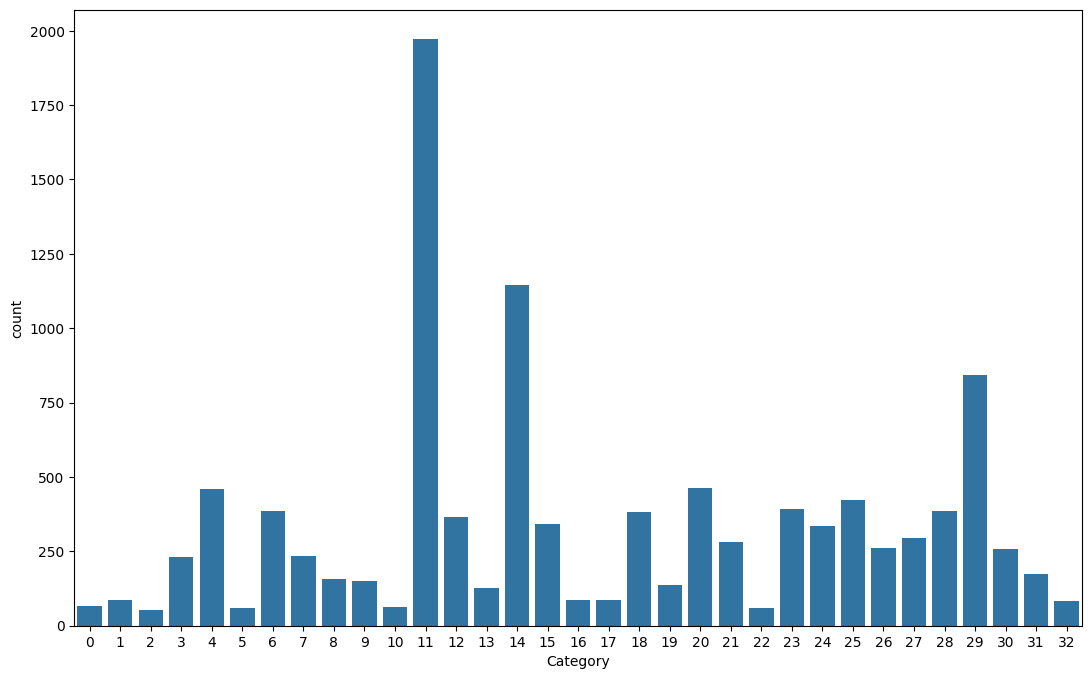

In [34]:
plt.figure(figsize=(13,8))
sns.countplot(x ='Category', data = df)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10840 entries, 0 to 10839
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  int64  
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            10840 non-null  int64  
 5   Installs        10840 non-null  int64  
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  float64
 8   Content Rating  10840 non-null  int64  
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(2), int64(5), object(6)
memory usage: 1.1+ MB


In [36]:
df['Last Updated'] = pd.to_datetime(df['Last Updated']) # convert to datetime

In [37]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,0,4.1,159,19000000,10000,Free,0.0,0,Art & Design,2018-01-07,1.0.0,4.0.3 and up
1,Coloring book moana,0,3.9,967,14000000,500000,Free,0.0,0,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",0,4.7,87510,8700000,5000000,Free,0.0,0,Art & Design,2018-08-01,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,0,4.5,215644,25000000,50000000,Free,0.0,1,Art & Design,2018-06-08,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,0,4.3,967,2800000,100000,Free,0.0,0,Art & Design;Creativity,2018-06-20,1.1,4.4 and up


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10840 entries, 0 to 10839
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10840 non-null  object        
 1   Category        10840 non-null  int64         
 2   Rating          9366 non-null   float64       
 3   Reviews         10840 non-null  int64         
 4   Size            10840 non-null  int64         
 5   Installs        10840 non-null  int64         
 6   Type            10839 non-null  object        
 7   Price           10840 non-null  float64       
 8   Content Rating  10840 non-null  int64         
 9   Genres          10840 non-null  object        
 10  Last Updated    10840 non-null  datetime64[ns]
 11  Current Ver     10832 non-null  object        
 12  Android Ver     10838 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(5), object(5)
memory usage: 1.1+ MB


In [39]:
# extracting the year, month and day from the last updated column
df['Last Updated Year']  = df ['Last Updated'].dt.year
df['Last Updated Month']  = df ['Last Updated'].dt.month
df['Last Updated Day']  = df ['Last Updated'].dt.day



In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10840 entries, 0 to 10839
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   App                 10840 non-null  object        
 1   Category            10840 non-null  int64         
 2   Rating              9366 non-null   float64       
 3   Reviews             10840 non-null  int64         
 4   Size                10840 non-null  int64         
 5   Installs            10840 non-null  int64         
 6   Type                10839 non-null  object        
 7   Price               10840 non-null  float64       
 8   Content Rating      10840 non-null  int64         
 9   Genres              10840 non-null  object        
 10  Last Updated        10840 non-null  datetime64[ns]
 11  Current Ver         10832 non-null  object        
 12  Android Ver         10838 non-null  object        
 13  Last Updated Year   10840 non-null  int32     

In [41]:
df.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Last Updated Year,Last Updated Month,Last Updated Day
0,Photo Editor & Candy Camera & Grid & ScrapBook,0,4.1,159,19000000,10000,Free,0.0,0,Art & Design,2018-01-07,1.0.0,4.0.3 and up,2018,1,7
1,Coloring book moana,0,3.9,967,14000000,500000,Free,0.0,0,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,2018,1,15


In [42]:
df.drop('Last Updated', axis =1 , inplace = True ) # dropping the last updated column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10840 entries, 0 to 10839
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   App                 10840 non-null  object 
 1   Category            10840 non-null  int64  
 2   Rating              9366 non-null   float64
 3   Reviews             10840 non-null  int64  
 4   Size                10840 non-null  int64  
 5   Installs            10840 non-null  int64  
 6   Type                10839 non-null  object 
 7   Price               10840 non-null  float64
 8   Content Rating      10840 non-null  int64  
 9   Genres              10840 non-null  object 
 10  Current Ver         10832 non-null  object 
 11  Android Ver         10838 non-null  object 
 12  Last Updated Year   10840 non-null  int32  
 13  Last Updated Month  10840 non-null  int32  
 14  Last Updated Day    10840 non-null  int32  
dtypes: float64(2), int32(3), int64(5), object(5)
memory u

In [43]:
df.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Current Ver,Android Ver,Last Updated Year,Last Updated Month,Last Updated Day
0,Photo Editor & Candy Camera & Grid & ScrapBook,0,4.1,159,19000000,10000,Free,0.0,0,Art & Design,1.0.0,4.0.3 and up,2018,1,7
1,Coloring book moana,0,3.9,967,14000000,500000,Free,0.0,0,Art & Design;Pretend Play,2.0.0,4.0.3 and up,2018,1,15


In [44]:
df['Type'].unique()

array(['Free', 'Paid', nan], dtype=object)

In [45]:
df.Type.value_counts()

,count
Type,
Free,10039
Paid,800


In [46]:
df['Type'] = df['Type'].map({'Free': 1 , 'Paid': 2, np.nan : 0})


<Axes: xlabel='Type', ylabel='count'>

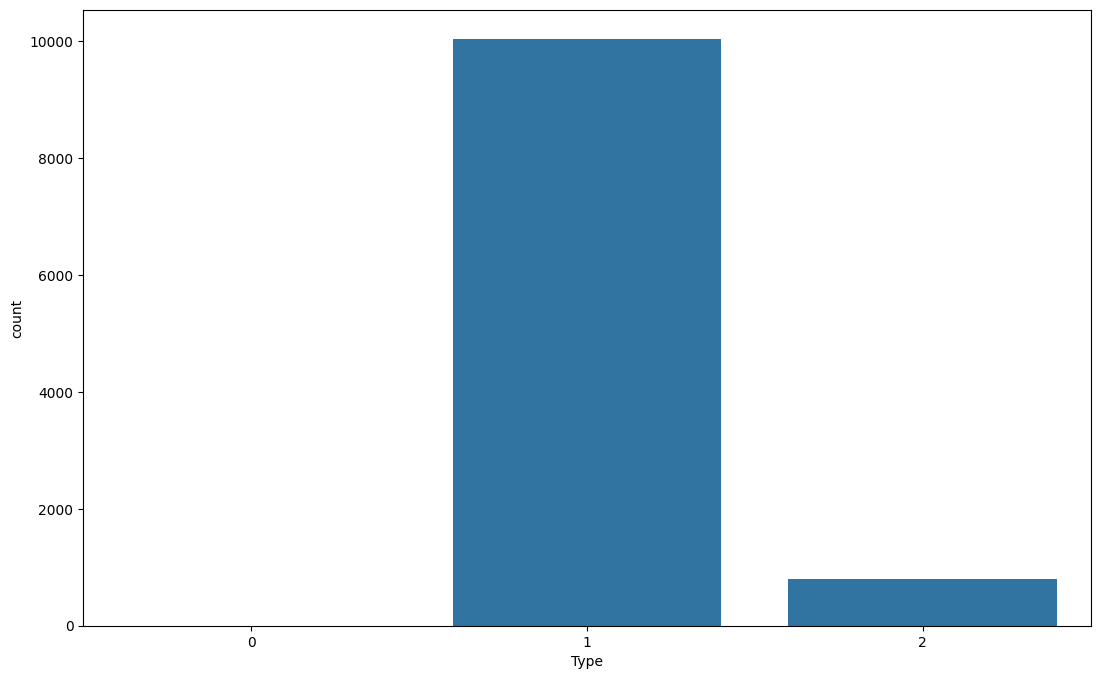

In [47]:
plt.figure(figsize=(13,8))
sns.countplot(x ='Type', data = df)

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10840 entries, 0 to 10839
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   App                 10840 non-null  object 
 1   Category            10840 non-null  int64  
 2   Rating              9366 non-null   float64
 3   Reviews             10840 non-null  int64  
 4   Size                10840 non-null  int64  
 5   Installs            10840 non-null  int64  
 6   Type                10840 non-null  int64  
 7   Price               10840 non-null  float64
 8   Content Rating      10840 non-null  int64  
 9   Genres              10840 non-null  object 
 10  Current Ver         10832 non-null  object 
 11  Android Ver         10838 non-null  object 
 12  Last Updated Year   10840 non-null  int32  
 13  Last Updated Month  10840 non-null  int32  
 14  Last Updated Day    10840 non-null  int32  
dtypes: float64(2), int32(3), int64(6), object(4)
memory u

In [49]:
df.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Current Ver,Android Ver,Last Updated Year,Last Updated Month,Last Updated Day
0,Photo Editor & Candy Camera & Grid & ScrapBook,0,4.1,159,19000000,10000,1,0.0,0,Art & Design,1.0.0,4.0.3 and up,2018,1,7
1,Coloring book moana,0,3.9,967,14000000,500000,1,0.0,0,Art & Design;Pretend Play,2.0.0,4.0.3 and up,2018,1,15


In [50]:
df['Current Ver'].unique()

array(['1.0.0', '2.0.0', '1.2.4', ..., '1.0.612928', '0.3.4', '2.0.148.0'],
      dtype=object)

In [51]:
df['Current Ver'].value_counts()

,count
Current Ver,
Varies with device,1459
1.0,809
1.1,264
1.2,178
2.0,151
...,...
0.15.2,1
0.7.1,1
4.6.71,1


In [52]:
# replacing the Varies with device with 0 and then extracting the first number
df['Current Ver'] = df['Current Ver'].str.replace('Varies with device','0.0')
df['Current Ver'] = df['Current Ver'].str.extract(r'(\d+\.\d+)').astype(float).fillna(0.0)

In [53]:
df.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Current Ver,Android Ver,Last Updated Year,Last Updated Month,Last Updated Day
0,Photo Editor & Candy Camera & Grid & ScrapBook,0,4.1,159,19000000,10000,1,0.0,0,Art & Design,1.0,4.0.3 and up,2018,1,7
1,Coloring book moana,0,3.9,967,14000000,500000,1,0.0,0,Art & Design;Pretend Play,2.0,4.0.3 and up,2018,1,15


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10840 entries, 0 to 10839
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   App                 10840 non-null  object 
 1   Category            10840 non-null  int64  
 2   Rating              9366 non-null   float64
 3   Reviews             10840 non-null  int64  
 4   Size                10840 non-null  int64  
 5   Installs            10840 non-null  int64  
 6   Type                10840 non-null  int64  
 7   Price               10840 non-null  float64
 8   Content Rating      10840 non-null  int64  
 9   Genres              10840 non-null  object 
 10  Current Ver         10840 non-null  float64
 11  Android Ver         10838 non-null  object 
 12  Last Updated Year   10840 non-null  int32  
 13  Last Updated Month  10840 non-null  int32  
 14  Last Updated Day    10840 non-null  int32  
dtypes: float64(3), int32(3), int64(6), object(3)
memory u

In [55]:
df['Current Ver'].value_counts()

,count
Current Ver,
0.00,1710
1.00,1678
1.10,602
1.20,444
2.00,378
...,...
1.72,1
6.04,1
1.59,1


In [56]:
df['Android Ver'].value_counts()

,count
Android Ver,
4.1 and up,2451
4.0.3 and up,1501
4.0 and up,1375
Varies with device,1362
4.4 and up,980
2.3 and up,652
5.0 and up,601
4.2 and up,394
2.3.3 and up,281


<Axes: xlabel='count', ylabel='Android Ver'>

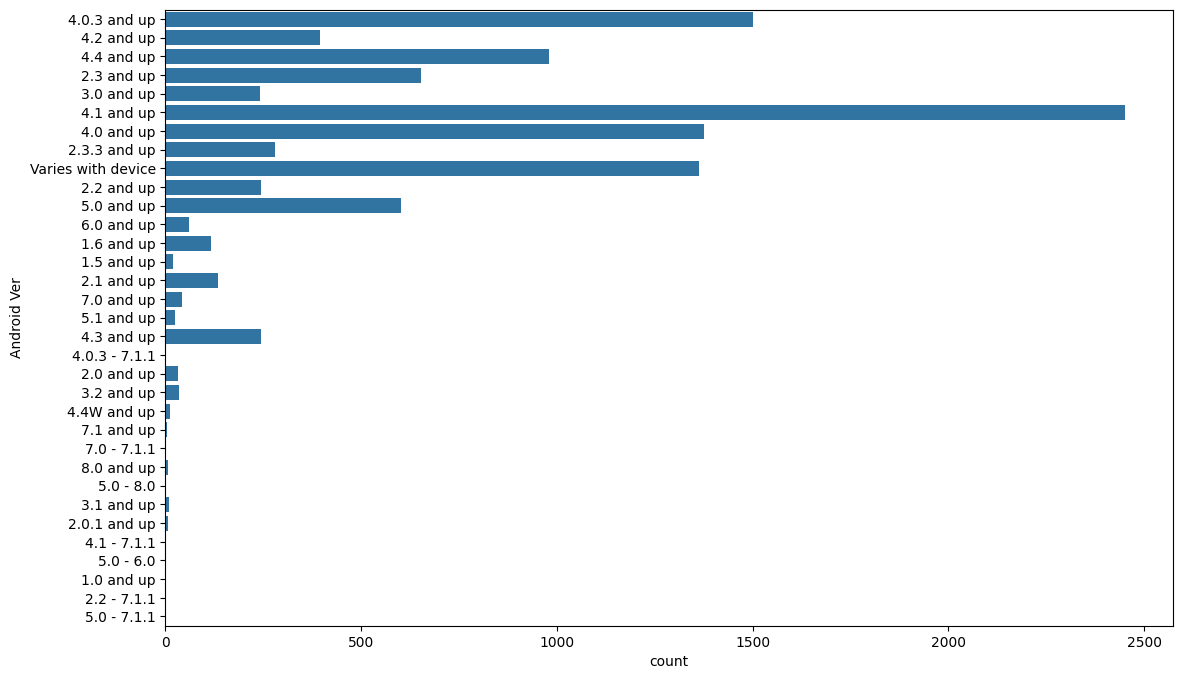

In [57]:
plt.figure(figsize=(13,8))
sns.countplot(df['Android Ver'])

In [58]:
# Applying label encoding to Android Ver
df['Android Ver'] = le.fit_transform(df['Android Ver'])

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10840 entries, 0 to 10839
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   App                 10840 non-null  object 
 1   Category            10840 non-null  int64  
 2   Rating              9366 non-null   float64
 3   Reviews             10840 non-null  int64  
 4   Size                10840 non-null  int64  
 5   Installs            10840 non-null  int64  
 6   Type                10840 non-null  int64  
 7   Price               10840 non-null  float64
 8   Content Rating      10840 non-null  int64  
 9   Genres              10840 non-null  object 
 10  Current Ver         10840 non-null  float64
 11  Android Ver         10840 non-null  int64  
 12  Last Updated Year   10840 non-null  int32  
 13  Last Updated Month  10840 non-null  int32  
 14  Last Updated Day    10840 non-null  int32  
dtypes: float64(3), int32(3), int64(7), object(2)
memory u

In [60]:
df.Genres.unique()

array(['Art & Design', 'Art & Design;Pretend Play',
       'Art & Design;Creativity', 'Art & Design;Action & Adventure',
       'Auto & Vehicles', 'Beauty', 'Books & Reference', 'Business',
       'Comics', 'Comics;Creativity', 'Communication', 'Dating',
       'Education;Education', 'Education', 'Education;Creativity',
       'Education;Music & Video', 'Education;Action & Adventure',
       'Education;Pretend Play', 'Education;Brain Games', 'Entertainment',
       'Entertainment;Music & Video', 'Entertainment;Brain Games',
       'Entertainment;Creativity', 'Events', 'Finance', 'Food & Drink',
       'Health & Fitness', 'House & Home', 'Libraries & Demo',
       'Lifestyle', 'Lifestyle;Pretend Play',
       'Adventure;Action & Adventure', 'Arcade', 'Casual', 'Card',
       'Casual;Pretend Play', 'Action', 'Strategy', 'Puzzle', 'Sports',
       'Music', 'Word', 'Racing', 'Casual;Creativity',
       'Casual;Action & Adventure', 'Simulation', 'Adventure', 'Board',
       'Trivia', 'Role 

In [61]:
# Extracting Primary Genres from Genres
df['Primary Genres'] = df['Genres'].str.split(';').str[0]

In [62]:
df['Primary Genres'].unique()

array(['Art & Design', 'Auto & Vehicles', 'Beauty', 'Books & Reference',
       'Business', 'Comics', 'Communication', 'Dating', 'Education',
       'Entertainment', 'Events', 'Finance', 'Food & Drink',
       'Health & Fitness', 'House & Home', 'Libraries & Demo',
       'Lifestyle', 'Adventure', 'Arcade', 'Casual', 'Card', 'Action',
       'Strategy', 'Puzzle', 'Sports', 'Music', 'Word', 'Racing',
       'Simulation', 'Board', 'Trivia', 'Role Playing', 'Educational',
       'Music & Audio', 'Video Players & Editors', 'Medical', 'Social',
       'Shopping', 'Photography', 'Travel & Local', 'Tools',
       'Personalization', 'Productivity', 'Parenting', 'Weather',
       'News & Magazines', 'Maps & Navigation', 'Casino'], dtype=object)

In [63]:
# Extracting Secendary Genres from Genres
df['Secendary Genres'] = df['Genres'].str.split(';').str[1]

In [64]:
df['Secendary Genres'].unique()

array([nan, 'Pretend Play', 'Creativity', 'Action & Adventure',
       'Education', 'Music & Video', 'Brain Games'], dtype=object)

In [65]:
df['Secendary Genres'].value_counts()

,count
Secendary Genres,
Action & Adventure,138
Education,116
Pretend Play,90
Brain Games,70
Music & Video,47
Creativity,37


In [66]:
# Applying label encoding to Primary Genres
df['Primary Genres'] = le.fit_transform(df['Primary Genres'])

In [67]:
df.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Current Ver,Android Ver,Last Updated Year,Last Updated Month,Last Updated Day,Primary Genres,Secendary Genres
0,Photo Editor & Candy Camera & Grid & ScrapBook,0,4.1,159,19000000,10000,1,0.0,0,Art & Design,1.0,15,2018,1,7,3,NaN
1,Coloring book moana,0,3.9,967,14000000,500000,1,0.0,0,Art & Design;Pretend Play,2.0,15,2018,1,15,3,Pretend Play


<Axes: xlabel='Primary Genres', ylabel='count'>

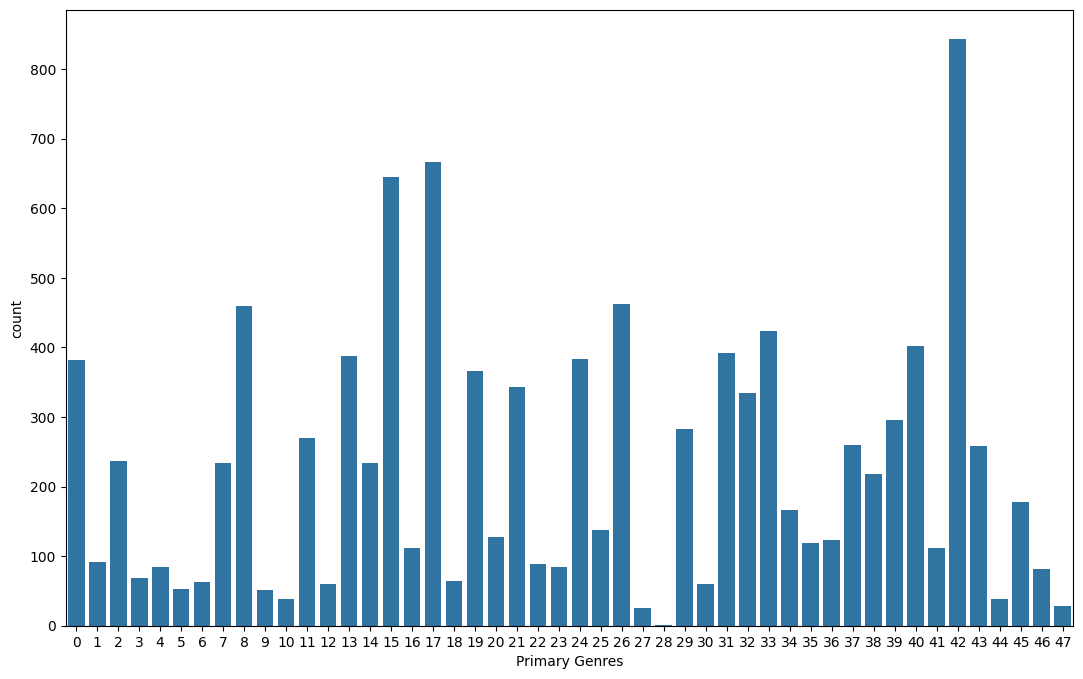

In [68]:
plt.figure(figsize=(13,8))
sns.countplot(x ='Primary Genres', data = df)

In [69]:
# Applying label encoding to Secendary Genres
df['Secendary Genres'] = le.fit_transform(df['Secendary Genres'])

In [70]:
df.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Current Ver,Android Ver,Last Updated Year,Last Updated Month,Last Updated Day,Primary Genres,Secendary Genres
0,Photo Editor & Candy Camera & Grid & ScrapBook,0,4.1,159,19000000,10000,1,0.0,0,Art & Design,1.0,15,2018,1,7,3,6
1,Coloring book moana,0,3.9,967,14000000,500000,1,0.0,0,Art & Design;Pretend Play,2.0,15,2018,1,15,3,5


In [71]:
df['Secendary Genres'].value_counts()

,count
Secendary Genres,
6,10342
0,138
3,116
5,90
1,70
4,47
2,37


<Axes: xlabel='Secendary Genres', ylabel='count'>

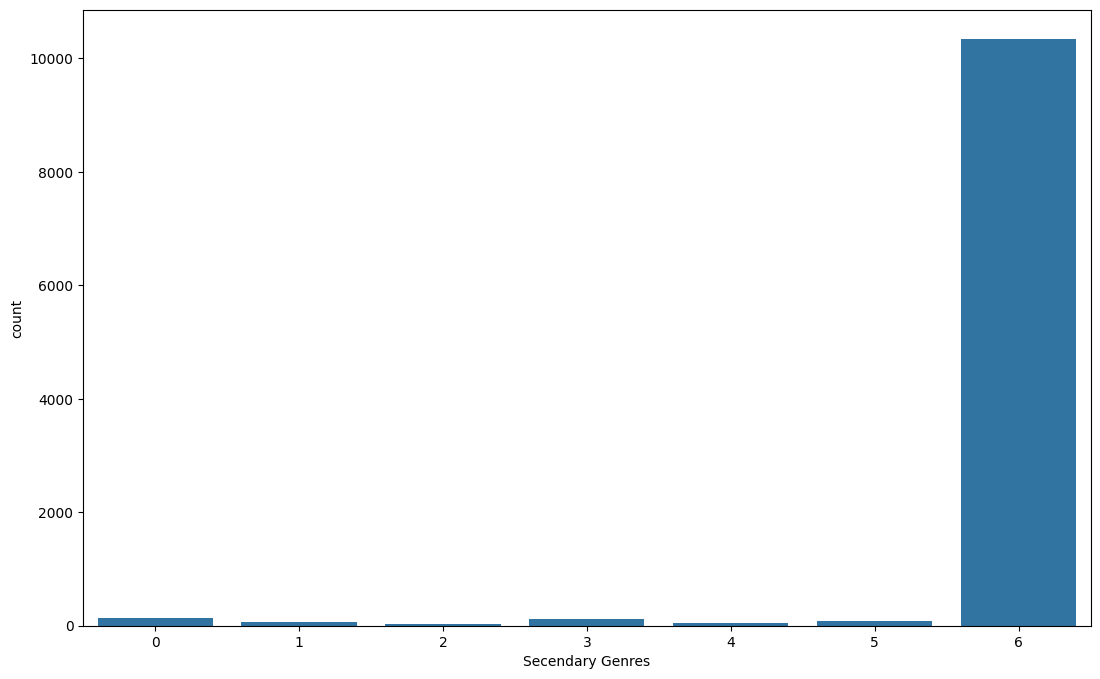

In [72]:
plt.figure(figsize=(13,8))
sns.countplot(x ='Secendary Genres', data = df)

In [73]:
df.drop('Genres', axis=1, inplace=True) # dropping the Genres column

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10840 entries, 0 to 10839
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   App                 10840 non-null  object 
 1   Category            10840 non-null  int64  
 2   Rating              9366 non-null   float64
 3   Reviews             10840 non-null  int64  
 4   Size                10840 non-null  int64  
 5   Installs            10840 non-null  int64  
 6   Type                10840 non-null  int64  
 7   Price               10840 non-null  float64
 8   Content Rating      10840 non-null  int64  
 9   Current Ver         10840 non-null  float64
 10  Android Ver         10840 non-null  int64  
 11  Last Updated Year   10840 non-null  int32  
 12  Last Updated Month  10840 non-null  int32  
 13  Last Updated Day    10840 non-null  int32  
 14  Primary Genres      10840 non-null  int64  
 15  Secendary Genres    10840 non-null  int64  
dtypes: f

In [75]:
df['App'].unique()

array(['Photo Editor & Candy Camera & Grid & ScrapBook',
       'Coloring book moana',
       'U Launcher Lite – FREE Live Cool Themes, Hide Apps', ...,
       'Parkinson Exercices FR', 'The SCP Foundation DB fr nn5n',
       'iHoroscope - 2018 Daily Horoscope & Astrology'], dtype=object)

In [76]:
#leaving this column app as it might be used for  text analysis after .

## Feature Engineering

In [77]:
df.isnull().sum()

,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,0
Price,0
Content Rating,0
Current Ver,0


<Axes: xlabel='Rating', ylabel='count'>

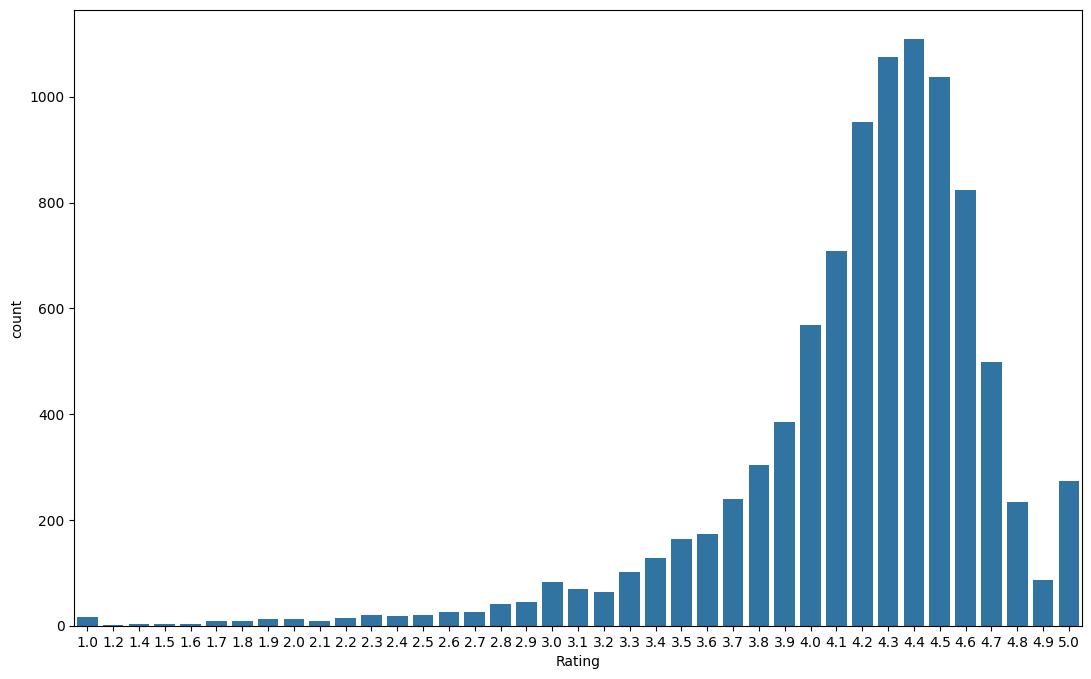

In [78]:
plt.figure(figsize=(13,8))
sns.countplot(x ='Rating', data = df)

In [79]:
#filling thsi with the mean of rating
df['Rating'].fillna(df['Rating'].mean(), inplace = True)

/tmp/ipykernel_17857/407528913.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Rating'].fillna(df['Rating'].mean(), inplace = True)


In [80]:
df.to_csv('cleaned_googleplaystore.csv', index=False)